In [1]:
import sys
from pathlib import Path
import sys
import re

project_root = Path.cwd().parent   # or Path.cwd(), depending on notebook location
sys.path.append(str(project_root))
print(project_root)

from package.linePlotUtils import *
from package.scatterPlotUtils import *
from package.HeatmapUtil import *


d:\bxn_lu\recovered\3rdyear\internship\intern


In [21]:
All_Data = {}
folder = Path("FinalDataCollection/Smoothen")
while True:
    if not folder.exists():
        print(f"Folder not found: {folder.resolve()}")
        break

    for filepath in sorted(folder.glob("*.csv")):
        print(f"Processing {filepath.name}")
        try:
            df = pd.read_csv(filepath)
            # print(df.head())

            # For HeatMap (contact area usage)
            processingColumnNP, _, rising_edges, edge_length1 = detect_rising_edges(df, "SumForce", column="SumForce")
            print(f"Rising edges detected at indices: {rising_edges}")
            print(f"Minimum edge lengths: {edge_length1}")

            # print(df.iloc[rising_edges[3]:rising_edges[3]+int(edge_length)])  # Display the first few rows of the processed DataFrame
            cutDFforHeatMap = []
            for i, value in enumerate(rising_edges):
                start_index = value
                end_index = start_index + edge_length1[i] # delete the last 20 points to avoid the end of the signal
                df_reindexed = df.iloc[start_index:end_index].reset_index(drop=True)
                # print(df_reindexed.head())  # Display the first few rows of the cut DataFrame
                cutDFforHeatMap.append(df_reindexed)
            print(f"Cut DataFrames created: {len(cutDFforHeatMap)} segments")



            # For detecting force application time
            touching_points, edge_length2 = detect_touching_point(df, "pos_z[mm]")
            print(f"Touching points detected at indices: {touching_points}")
            print(f"Minimum edge lengths: {edge_length2}")

            cutDFforForceTime = []
            for i, value in enumerate(touching_points):
                start_index = value
                end_index = start_index + edge_length2[i]# delete the last 20 points to avoid the end of the signal
                df_reindexed = df.iloc[start_index:end_index].reset_index(drop=True)
                # print(df_reindexed.head())  # Display the first few rows of the cut DataFrame
                cutDFforForceTime.append(df_reindexed)
            print(f"Cut DataFrames created: {len(cutDFforForceTime)} segments")

            # for i, segment in enumerate(cutDFforForceTime):
            #     plot2SignalAllCSV(segment, "SumForce", "pos_z[mm]")

            All_Data[filepath.name] = {
                # Convert every DataFrame inside the 'ForHeatMap' list
                'ForHeatMap': cutDFforHeatMap,

                # Convert every DataFrame inside the 'ForForceTime' list
                'ForForceTime': cutDFforForceTime
            }
            print(len(All_Data[filepath.name]['ForForceTime']))

            # for i, segment in enumerate(All_Data[filepath.name]['ForHeatMap']):
            #     plot2SignalAllCSV(segment, "pos_x[mm]", "pos_z[mm]")
            # print(" ")


        except Exception as e:
            print(f"Failed: {filepath.name}")
            print(e)
    print(len(All_Data))
    break

Processing AoFoam1.csv
Rising edges detected at indices: [ 441 1196 1883 2552 3180]
Minimum edge lengths: [435 433 422 362 383]
Cut DataFrames created: 5 segments
Touching points detected at indices: [ 415 1155 1849 2528 3152]
Minimum edge lengths: [464 478 463 384 414]
Cut DataFrames created: 5 segments
5
Processing AoFoam2.csv
Rising edges detected at indices: [ 305 1035 1778 2533 3201]
Minimum edge lengths: [483 481 466 420 435]
Cut DataFrames created: 5 segments
Touching points detected at indices: [ 280 1009 1742 2511 3173]
Minimum edge lengths: [513 509 508 445 476]
Cut DataFrames created: 5 segments
5
Processing AoPillow1.csv
Rising edges detected at indices: [ 447 1215 2009 2645 3344]
Minimum edge lengths: [467 470 371 427 409]
Cut DataFrames created: 5 segments
Touching points detected at indices: [ 377 1168 1971 2609 3308]
Minimum edge lengths: [549 544 428 489 458]
Cut DataFrames created: 5 segments
5
Processing AoPillow2.csv
Rising edges detected at indices: [ 325 1015 1731

In [26]:
force_columns = [
    "SumForcePalm", "V_SidePalm[N]", "V_ThumbPalm[N]", "V_UpperPalm[N]", "V_Index[N]", "V_Thumb[N]",
]
max_force = [160, 80, 80, 80, 20, 50]  # same order as force_columns

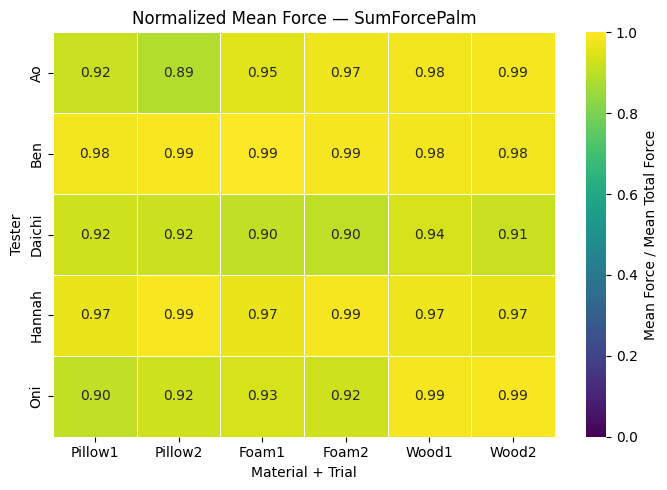

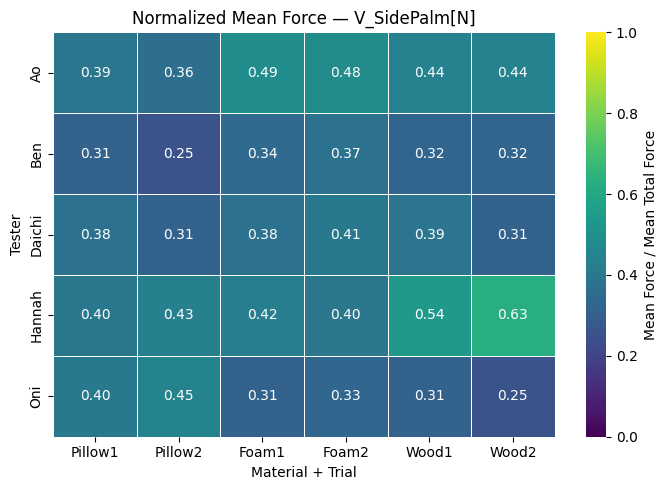

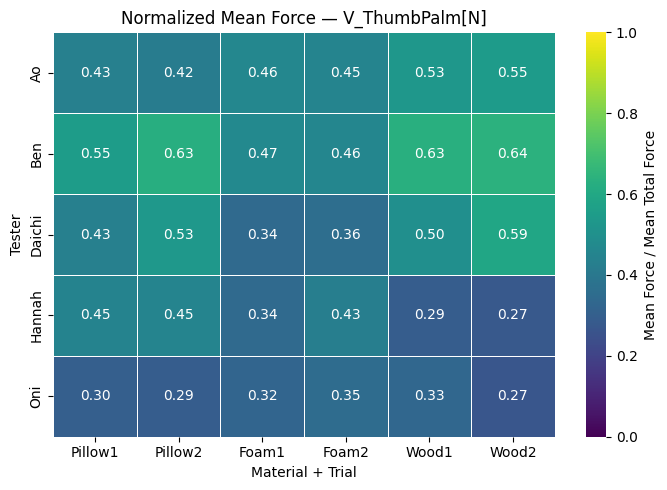

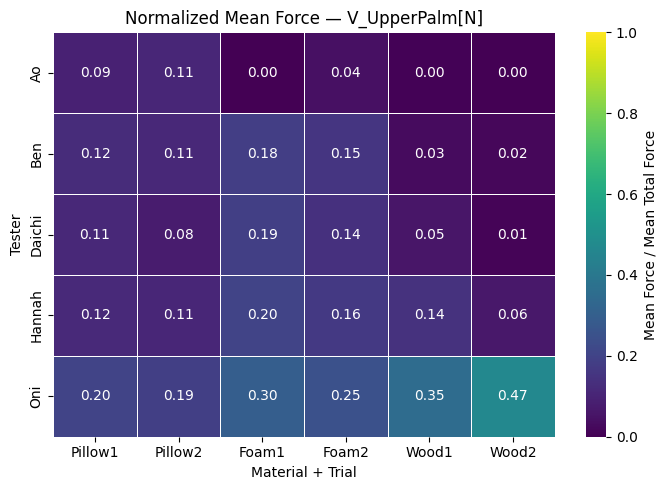

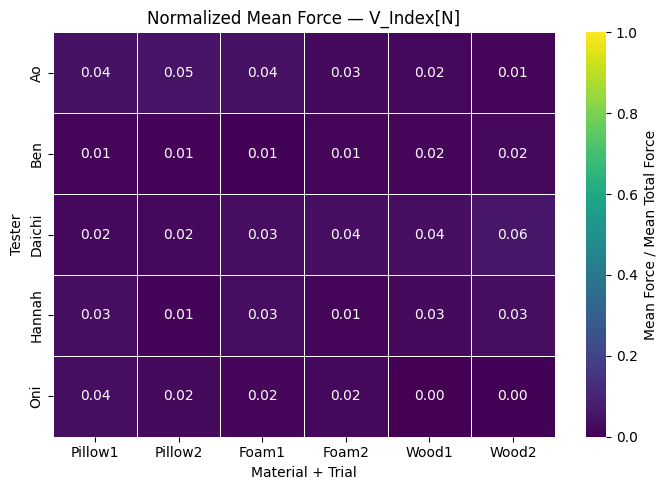

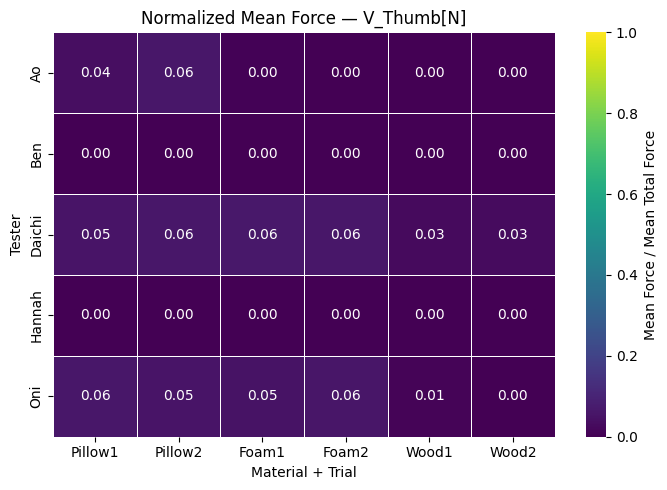

In [27]:
heatmaps = build_contact_force_heatmaps(
    All_Data,
    force_columns,
    parse_filename = parse_filename_tester_material_trial,  # still needs your real filename logic
    normalize="sum_force",       # <-- new mode, no max_force needed
    sum_column="SumForce",
    # normalize="fixed",
    # max_force=max_force,
    column_order=["Pillow1", "Pillow2", "Foam1", "Foam2", "Wood1", "Wood2"],
    # save_path="Data/Finaloutputs/contact_heatmap",
)

In [ ]:
surface_pivot = build_surface_vs_material_heatmap(
    All_Data,
    force_columns,
    parse_filename=parse_filename_tester_material_trial,
    normalize="fixed",
    max_force=max_force,
    column_order=["Pillow1", "Pillow2", "Foam1", "Foam2", "Wood1", "Wood2"],
    row_order=["ThumbPalm", "SidePalm", "UpperPalm", "Index", "Middle", "Thumb"],
    # save_path="outputs/surface_heatmap.png",
)

In [ ]:
per_tester_pivots = build_surface_vs_material_heatmap_per_tester(
    All_Data,
    force_columns,
    parse_filename=parse_filename_tester_material_trial,
    normalize="fixed",
    max_force=max_force,
    column_order=["Pillow1", "Pillow2", "Foam1", "Foam2", "Wood1", "Wood2"],
    row_order=["ThumbPalm", "SidePalm", "UpperPalm", "Index", "Middle", "Thumb"],
    # save_path="outputs/surface_heatmap",  # -> outputs/surface_heatmap_Ao.png, outputs/surface_heatmap_Sam.png, ...
)

Note: labels not in the provided order were appended at the end: ['SumForcePalm']


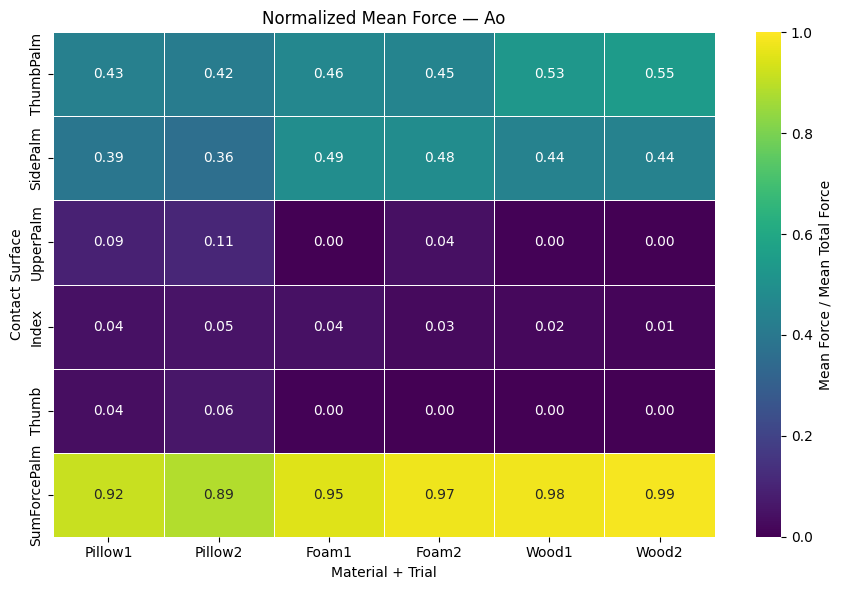

Note: labels not in the provided order were appended at the end: ['SumForcePalm']


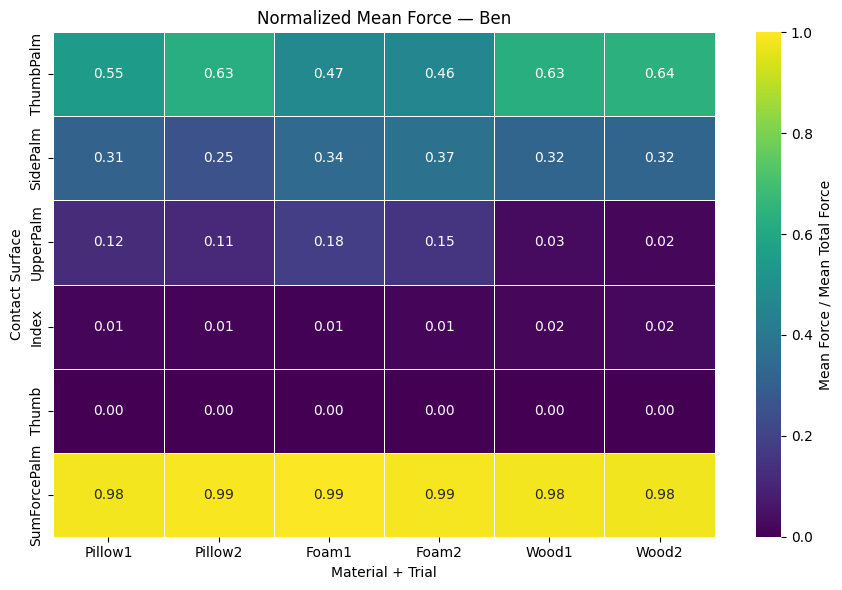

Note: labels not in the provided order were appended at the end: ['SumForcePalm']


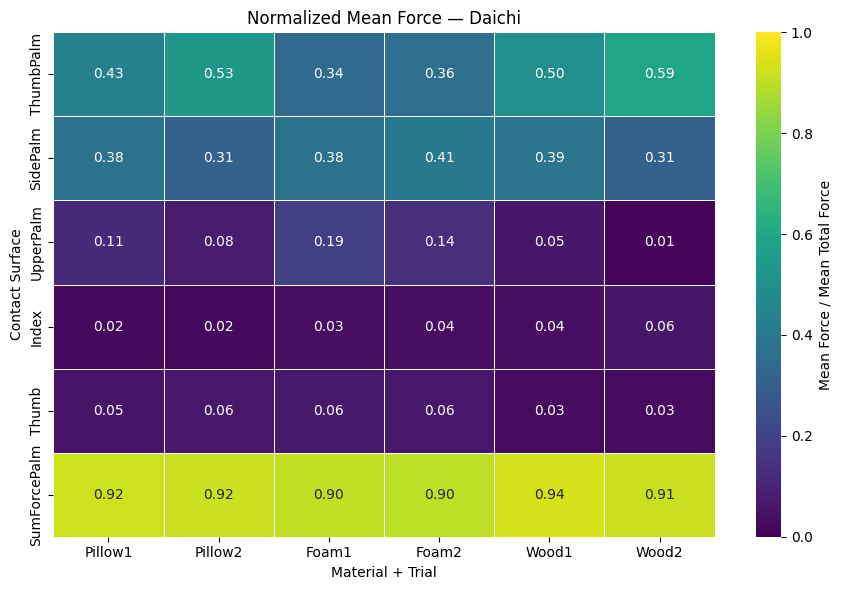

Note: labels not in the provided order were appended at the end: ['SumForcePalm']


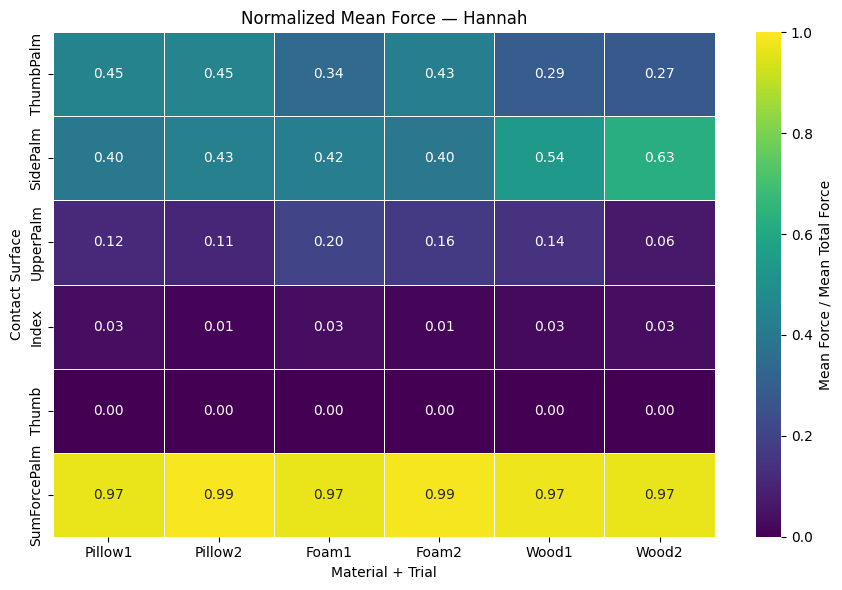

Note: labels not in the provided order were appended at the end: ['SumForcePalm']


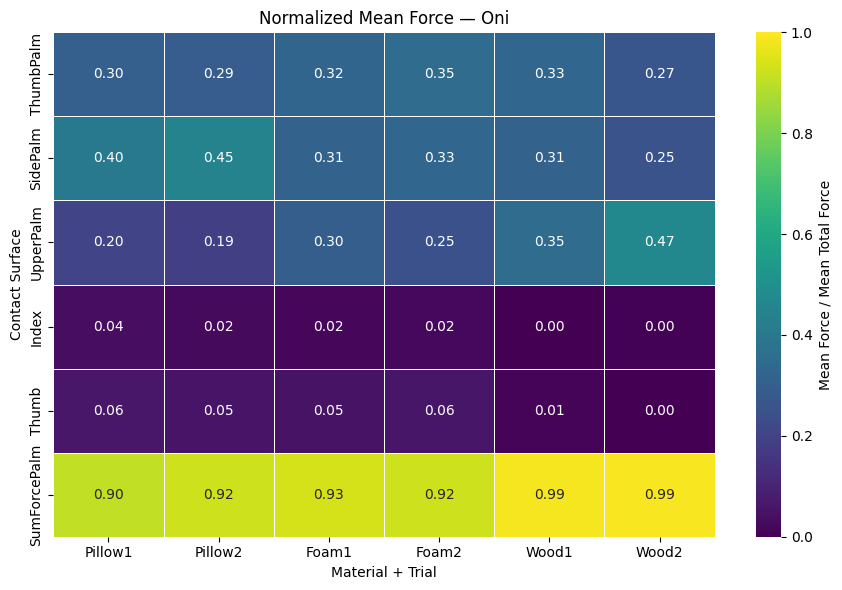

In [32]:
per_tester_share = build_surface_vs_material_heatmap_per_tester(
    All_Data,
    force_columns,
    parse_filename=parse_filename_tester_material_trial,
    normalize="sum_force",       # <-- new mode, no max_force needed
    sum_column="SumForce",       # column in your CSVs holding total force
    column_order=["Pillow1", "Pillow2", "Foam1", "Foam2", "Wood1", "Wood2"],
    row_order=["ThumbPalm", "SidePalm", "UpperPalm", "Index", "Middle", "Thumb"],
    # save_path="outputs/surface_share_heatmap",
)

Note: labels not in the provided order were appended at the end: ['SumForcePalm']


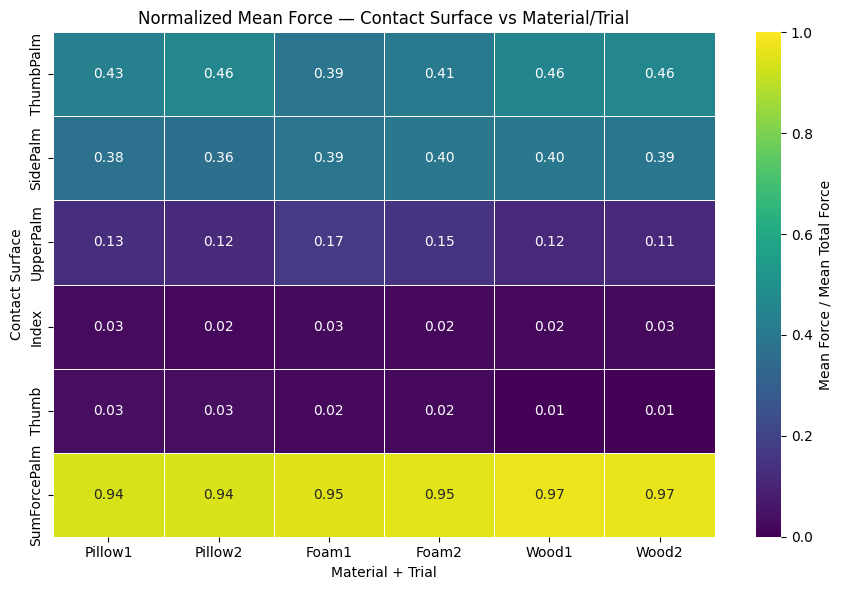

In [28]:
surface_pivot = build_surface_vs_material_heatmap(
    All_Data,
    force_columns,
    parse_filename=parse_filename_tester_material_trial,
    normalize="sum_force",       # <-- new mode, no max_force needed
    sum_column="SumForce",
    column_order=["Pillow1", "Pillow2", "Foam1", "Foam2", "Wood1", "Wood2"],
    row_order=["ThumbPalm", "SidePalm", "UpperPalm", "Index", "Middle", "Thumb"],
    # save_path="outputs/surface_heatmap.png",
)

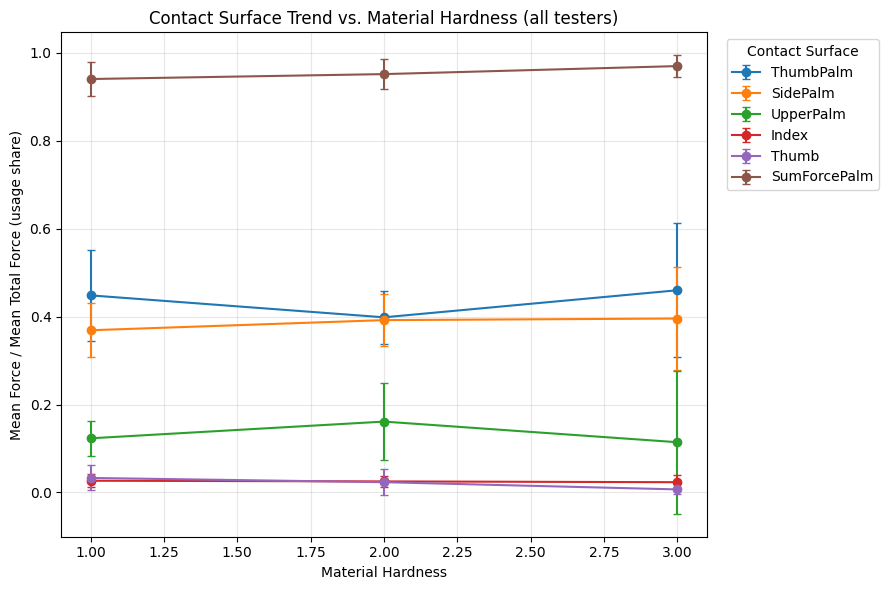

              spearman_r  spearman_p     slope  intercept  n_points
surface                                                            
ThumbPalm       0.047167    0.804519  0.005831   0.423844        30
SidePalm        0.037733    0.843075  0.013324   0.358859        30
UpperPalm      -0.198100    0.294004 -0.004454   0.141777        30
Index          -0.108483    0.568252 -0.001667   0.028365        30
Thumb          -0.383766    0.036297 -0.013034   0.047155        30
SumForcePalm    0.297150    0.110789  0.014701   0.924481        30


In [33]:
trend_stats, plotted_data = analyze_surface_hardness_trend(
    All_Data,
    force_columns,
    hardness_order=["Pillow", "Foam", "Wood"],       # soft -> hard, or a dict of real hardness values
    parse_filename=parse_filename_tester_material_trial,
    normalize="sum_force",   # usage share, independent of grip strength — recommended
    surface_order=["ThumbPalm", "SidePalm", "UpperPalm", "Index", "Thumb", "SumForcePalm"],
    # save_path="outputs/hardness_trend.png",
)
print(trend_stats)

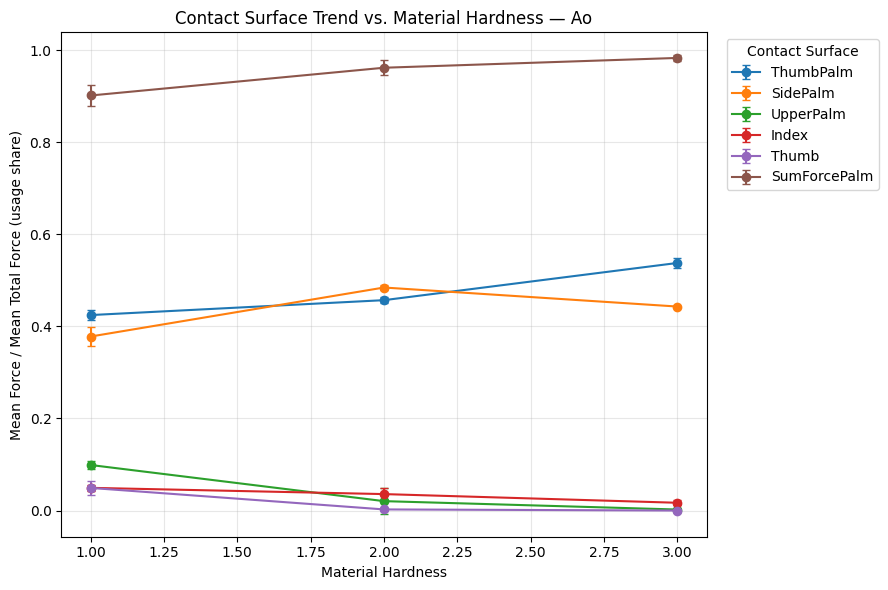

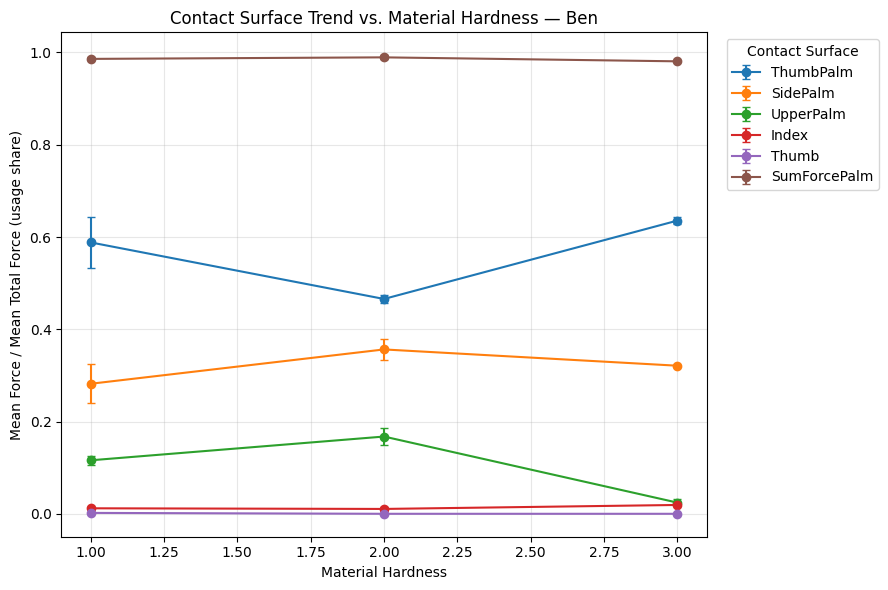

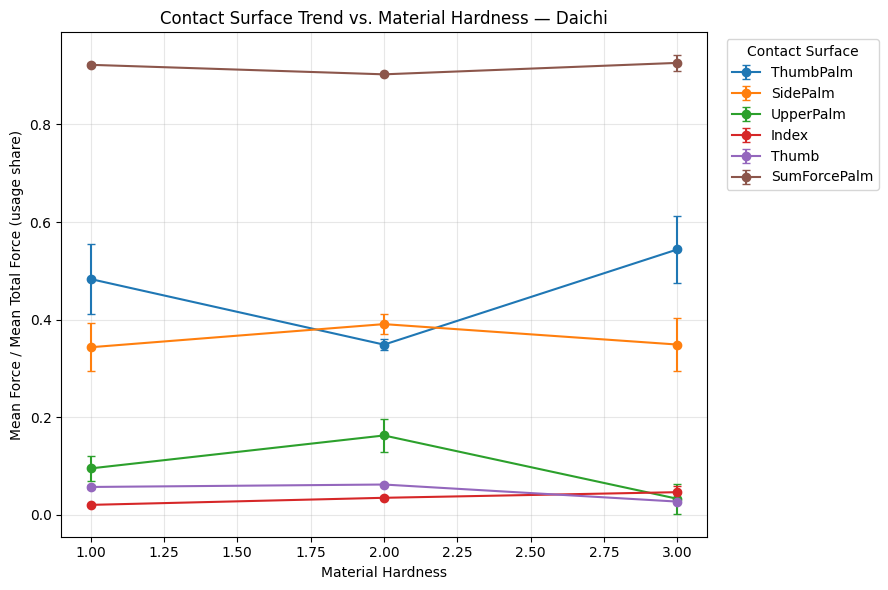

d:\bxn_lu\recovered\3rdyear\internship\intern\Data\package\HeatmapUtil.py:586: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  rho, p = spearmanr(sub["hardness"], sub[value_col])


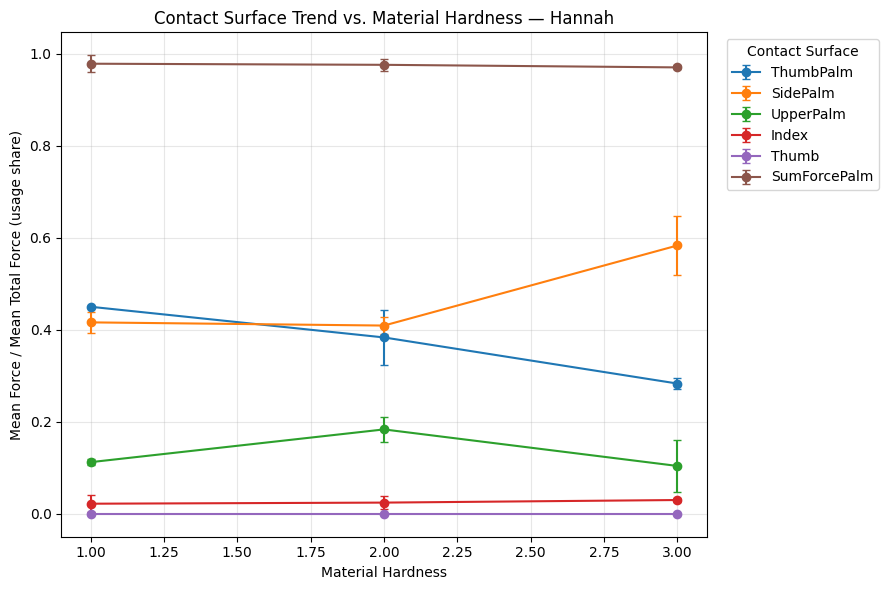

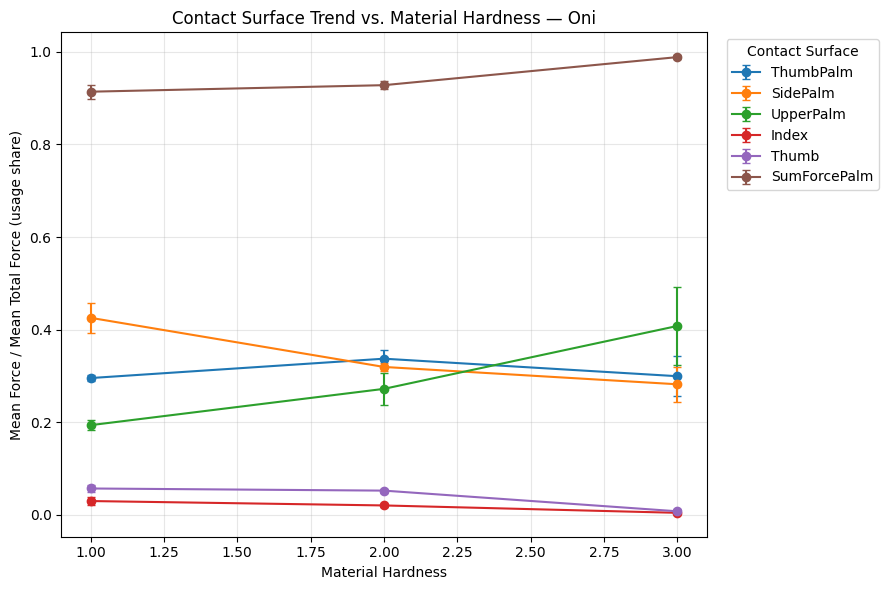

--- Ao ---
              spearman_r  spearman_p     slope  intercept  n_points
surface                                                            
ThumbPalm       0.956183    0.002838  0.056594   0.359920         6
SidePalm        0.478091    0.337502  0.032549   0.370079         6
UpperPalm      -0.836660    0.037841 -0.048347   0.137223         6
Index          -0.836660    0.037841 -0.016221   0.066430         6
Thumb          -0.889001    0.017797 -0.024575   0.066348         6
SumForcePalm    0.956183    0.002838  0.040796   0.867222         6
--- Ben ---
              spearman_r  spearman_p     slope  intercept  n_points
surface                                                            
ThumbPalm       0.478091    0.337502  0.023651   0.515909         6
SidePalm        0.478091    0.337502  0.019572   0.280585         6
UpperPalm      -0.478091    0.337502 -0.045868   0.194283         6
Index           0.597614    0.210295  0.003615   0.006635         6
Thumb          -0.848528 

In [30]:
per_tester_trends = analyze_surface_hardness_trend_per_tester(
    All_Data,
    force_columns,
    hardness_order=["Pillow", "Foam", "Wood"],
    parse_filename=parse_filename_tester_material_trial,
    normalize="sum_force",
    surface_order=["ThumbPalm", "SidePalm", "UpperPalm", "Index", "Thumb", "SumForcePalm"],
    # save_path="outputs/hardness_trend",  # -> outputs/hardness_trend_Ao.png, outputs/hardness_trend_Sam.png, ...
)

for tester, (stats, data) in per_tester_trends.items():
    print(f"--- {tester} ---")
    print(stats)